# Init

In [5]:
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
class ImageProcessor:
    def __init__(self, image: np.ndarray):
        assert len(image.shape) == 3 and image.shape[2] == 3, "Image must be an RGB image"
        self.original_image = image
        self.gray_image = None
        self.binary_image = None
        self.vertical_projection = None
        self.horizontal_projection = None

    def to_grayscale(self) -> np.ndarray:
        self.gray_image = np.mean(self.original_image, axis=2).astype(np.uint8)
        return self.gray_image

    def to_binary(self, threshold: int = 128) -> np.ndarray:
        if self.gray_image is None:
            self.to_grayscale()
        self.binary_image = (self.gray_image > threshold).astype(np.uint8)
        return self.binary_image

    def compute_projections(self) -> tuple[np.ndarray, np.ndarray]:
        if self.binary_image is None:
            self.to_binary()
        self.vertical_projection = np.sum(self.binary_image, axis=1)
        self.horizontal_projection = np.sum(self.binary_image, axis=0)
        return self.vertical_projection, self.horizontal_projection

    @staticmethod
    def find_local_minima(projection: np.ndarray, window: int = 3) -> list[int]:
        minima = []
        for i in range(window, len(projection) - window):
            segment = projection[i - window:i + window + 1]
            if projection[i] == min(segment):
                minima.append(i)
        return minima

    @staticmethod
    def compute_statistics(projection: np.ndarray) -> dict:
        return {
            "mean": float(np.mean(projection)),
            "std": float(np.std(projection)),
            "min": int(np.min(projection)),
            "max": int(np.max(projection))
        }

    def plot_results(self, show: bool = True):
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        axs[0].imshow(self.original_image)
        axs[0].set_title("Original Image")

        axs[1].imshow(self.binary_image, cmap='gray')
        axs[1].set_title("Binary Image")

        axs[2].imshow(self.gray_image, cmap='gray')
        axs[2].set_title("Grayscale Image")

        for ax in axs:
            ax.axis("off")

        if show:
            plt.tight_layout()
            plt.show()

    def plot_projections(self):
        if self.vertical_projection is None or self.horizontal_projection is None:
            self.compute_projections()

        fig, axs = plt.subplots(2, 1, figsize=(12, 6))
        axs[0].bar(range(len(self.horizontal_projection)), self.horizontal_projection)
        axs[0].set_title("Horizontal Projection")

        axs[1].bar(range(len(self.vertical_projection)), self.vertical_projection)
        axs[1].set_title("Vertical Projection")

        plt.tight_layout()
        plt.show()

    def highlight_minima(self):
        if self.binary_image is None:
            self.to_binary()
        if self.vertical_projection is None or self.horizontal_projection is None:
            self.compute_projections()

        h_min = self.find_local_minima(self.horizontal_projection)
        v_min = self.find_local_minima(self.vertical_projection)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(self.binary_image, cmap='gray')

        for x in h_min:
            ax.axvline(x, color='red', linestyle='--', lw=1)
        for y in v_min:
            ax.axhline(y, color='blue', linestyle='--', lw=1)

        ax.set_title("Minimal on Binary Image")
        plt.tight_layout()
        plt.show()

    def export_projection_data(self) -> tuple[pd.DataFrame, pd.DataFrame]:
        n = len(self.horizontal_projection)
        m = len(self.vertical_projection)

        df_h = pd.DataFrame({
            'X': list(range(n)),
            'Частота': self.horizontal_projection,
            'Відносна частота': self.horizontal_projection / np.sum(self.horizontal_projection)
        })

        df_v = pd.DataFrame({
            'Y': list(range(m)),
            'Частота': self.vertical_projection,
            'Відносна частота': self.vertical_projection / np.sum(self.vertical_projection)
        })

        return df_h, df_v


# Load image

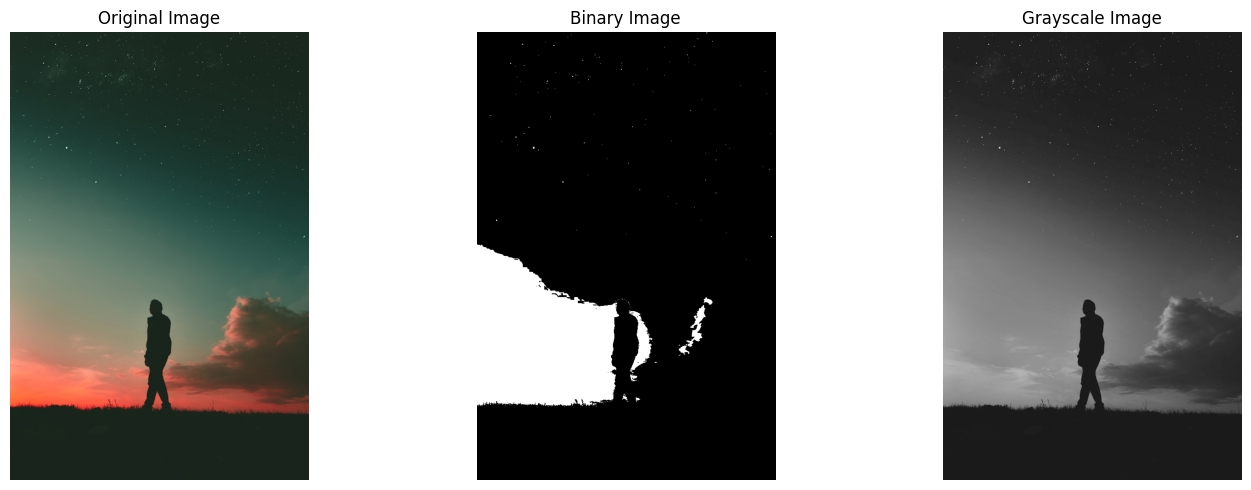

In [7]:
img = mpimg.imread('./imgs/img_1.jpg')[:, :, :3]

proc = ImageProcessor(img)
proc.to_binary(threshold=128)
proc.compute_projections()

proc.plot_results()

# Image projection

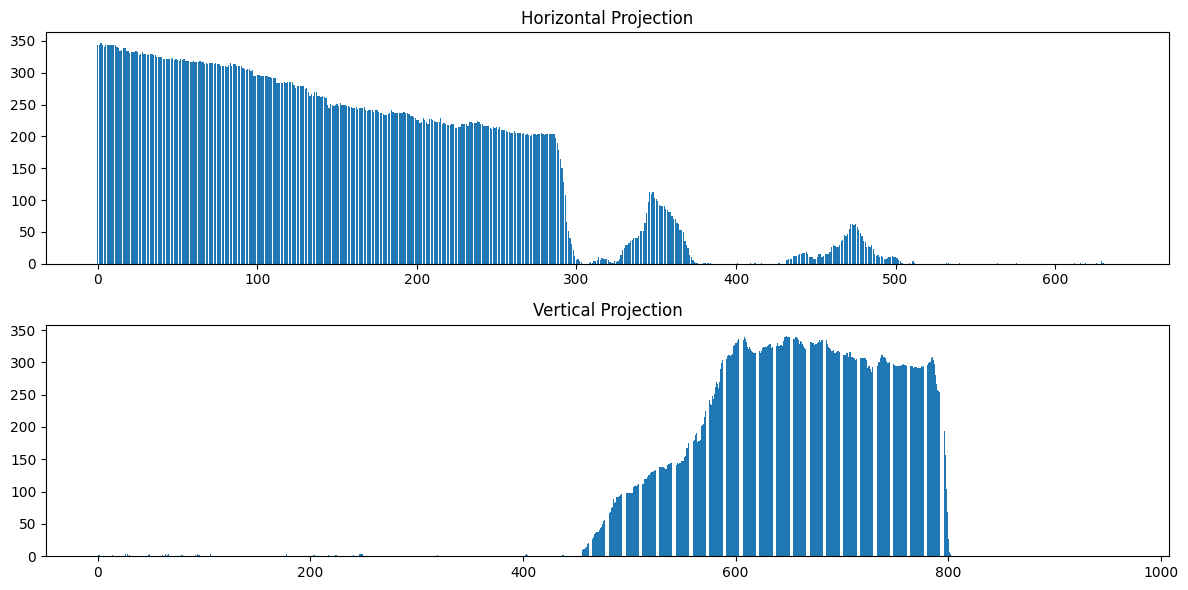

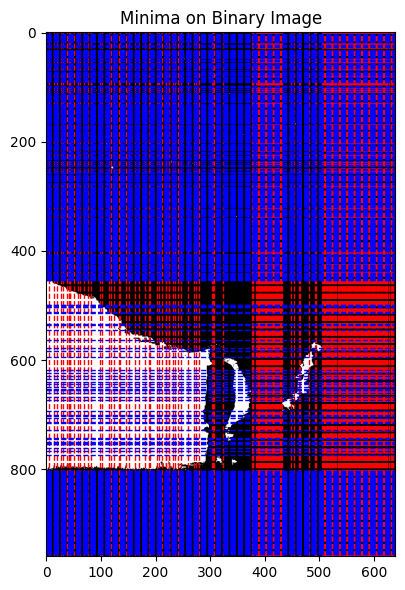

In [9]:
proc.plot_projections()
proc.highlight_minima()

# Statistics

In [12]:
horizontal_stats = proc.compute_statistics(proc.horizontal_projection)
vertical_stats = proc.compute_statistics(proc.vertical_projection)
print("Horizontal projection stats:", horizontal_stats)
print("Vertical projection stats:", vertical_stats)

Horizontal projection stats: {'mean': 128.996875, 'std': 130.71676199032154, 'min': 0, 'max': 346}
Vertical projection stats: {'mean': 85.99791666666667, 'std': 129.38371547066137, 'min': 0, 'max': 341}


In [18]:
df_h, df_v = proc.export_projection_data()
df_h, df_v

(       X  Частота  Відносна частота
 0      0      344          0.004167
 1      1      344          0.004167
 2      2      346          0.004191
 3      3      343          0.004155
 4      4      341          0.004130
 ..   ...      ...               ...
 635  635        0          0.000000
 636  636        0          0.000000
 637  637        0          0.000000
 638  638        0          0.000000
 639  639        0          0.000000
 
 [640 rows x 3 columns],
        Y  Частота  Відносна частота
 0      0        0          0.000000
 1      1        2          0.000024
 2      2        2          0.000024
 3      3        0          0.000000
 4      4        0          0.000000
 ..   ...      ...               ...
 955  955        0          0.000000
 956  956        0          0.000000
 957  957        0          0.000000
 958  958        0          0.000000
 959  959        0          0.000000
 
 [960 rows x 3 columns])